Sample Notebook to show how to download and convert SAFE data to Zarr

Install missing eopf package

In [ ]:
pip install eopf==2.6.2

Set CDSE S3 credentials, get them at https://eodata-s3keysmanager.dataspace.copernicus.eu/

In [ ]:
access_key = "CXJ4X1DAG8XKQEHFXQNJ"
secret_key = "chPR3UMwNo2O5DV7hIzKkbF0L6fJ2kwjNKRnaAaj"

Download a Sentinel-2 L2A product from the eodata bucket:

In [ ]:
import boto3
import os

session = boto3.session.Session()
s3 = boto3.resource(
    's3',
    endpoint_url='https://eodata.dataspace.copernicus.eu',
    aws_access_key_id=access_key,
    aws_secret_access_key=secret_key,
    region_name='default'
)  # generated secrets

def download(bucket, product: str, target: str = "") -> None:
    """
    Downloads every file in bucket with provided product as prefix

    Raises FileNotFoundError if the product was not found

    Args:
        bucket: boto3 Resource bucket object
        product: Path to product
        target: Local catalog for downloaded files. Should end with an `/`. Default current directory.
    """
    files = bucket.objects.filter(Prefix=product)
    if not list(files):
        raise FileNotFoundError(f"Could not find any files for {product}")
    for file in files:
        os.makedirs(os.path.dirname(file.key), exist_ok=True)
        if not os.path.isdir(file.key):
            bucket.download_file(file.key, f"{target}{file.key}")

# path to the product to download
download(s3.Bucket("eodata"), "Sentinel-2/MSI/L2A/2024/01/15/S2A_MSIL2A_20240115T235221_N0510_R130_T55HGS_20240116T021554.SAFE/")

Convert the product using eopf:

In [ ]:
# from dask_gateway import Gateway

# gate = Gateway()
# cluster = gate.new_cluster()
# cluster.scale(4)
# client = cluster.get_client()
# client

In [1]:
%%time

import os
from eopf.store.convert import convert
from eopf.common.constants import OpeningMode

path_to_safe  = os.path.join(os.getcwd(), 'Sentinel-2/MSI/L2A/2024/01/15/S2A_MSIL2A_20240115T235221_N0510_R130_T55HGS_20240116T021554.SAFE')
path_to_zarr = os.path.join(os.getcwd(), 'S2A_MSIL2A_20240115T235221_N0510_R130_T55HGS_20240116T021554.zarr')

# Add this parameter if you want to overwrite the output of the conversion if it already exists
target_store_config = dict(mode=OpeningMode.CREATE_OVERWRITE)

# Apply conversion
convert(path_to_safe, path_to_zarr, target_store_kwargs=target_store_config)


INFO:eopf.dask_utils.dask_context_manager:Initialising an ClusterType.LOCAL cluster with client conf : {} ,cluster config {'memory_limit': '8GiB', 'processes': True, 'threads_per_worker': 1} and dask config {}
INFO:eopf.dask_utils.dask_context_manager:DASK Cluster : LocalCluster(702d9b09, 'tcp://127.0.0.1:35667', workers=3, threads=3, memory=24.00 GiB)
INFO:eopf.dask_utils.dask_context_manager:Dask Client : <Client: 'tcp://127.0.0.1:35667' processes=4 threads=4, memory=32.00 GiB>
INFO:eopf.dask_utils.dask_context_manager:Dask dashboard address: http://127.0.0.1:8787/status
INFO:eopf.dask_utils.dask_context_manager:Waiting for 4 workers to be ready
INFO:eopf.store.convert:Converting /home/jovyan/workspace/Sentinel-2/MSI/L2A/2024/01/15/S2A_MSIL2A_20240115T235221_N0510_R130_T55HGS_20240116T021554.SAFE to /home/jovyan/workspace/S2A_MSIL2A_20240115T235221_N0510_R130_T55HGS_20240116T021554.zarr
INFO:eopf.store.safe:Found product type : S02MSIL2A with processing version: 04.00
/opt/conda/lib/

CPU times: user 19.1 s, sys: 2.92 s, total: 22 s
Wall time: 5min 20s


TimeoutError: 

In [3]:
import xarray as xr
dt = xr.open_datatree("S2A_MSIL2A_20240115T235221_N0510_R130_T55HGS_20240116T021554.zarr", chunks={}, engine="zarr", consolidated=False)

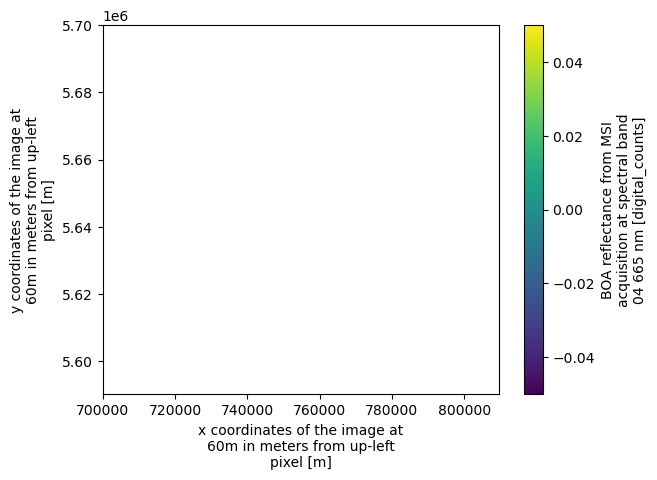

In [11]:
dt.measurements.reflectance.r60m.b04.plot.imshow()